## What Is a Residual Plot?

A residual is:


residual_i = y_i − y_i^

A residual plot helps detect:

- non-linearity

- heteroscedasticity

- outliers

- model misspecification

- independence issues

### PART 1 — Basic Residual Plot (Seaborn)

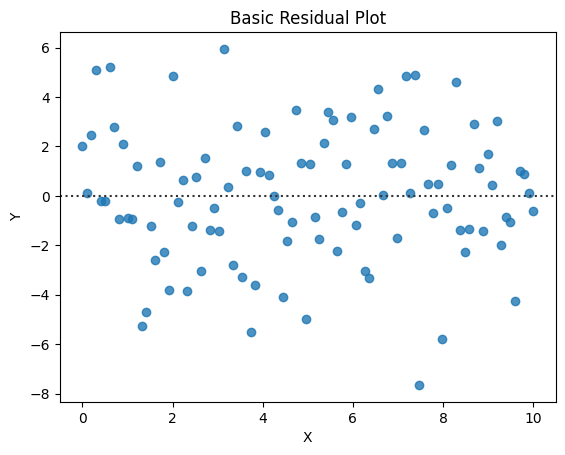

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 3 * x + np.random.normal(0, 3, 100)

df = pd.DataFrame({"X": x, "Y": y})

sns.residplot(x="X", y="Y", data=df)
plt.title("Basic Residual Plot")
plt.show()


### PART 2 — Residual Plot with LOWESS Smoothing

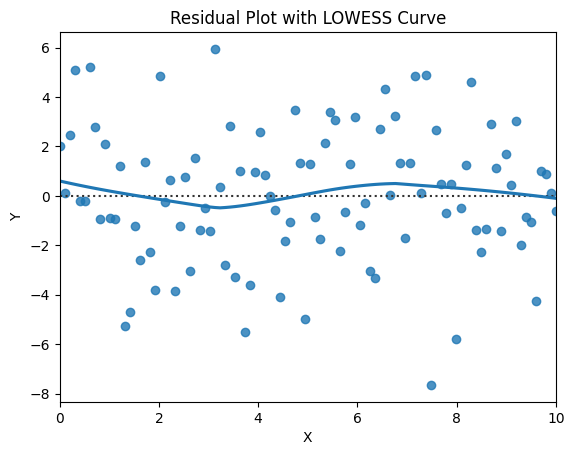

In [2]:

sns.residplot(
    x="X",
    y="Y",
    data=df,
    lowess=True
)

plt.title("Residual Plot with LOWESS Curve")
plt.show()


### PART 3 — Residuals vs Fitted Values (Manual)

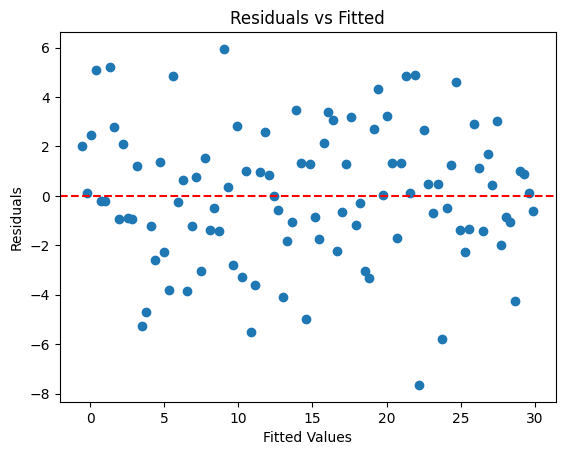

In [3]:
import statsmodels.api as sm

X = sm.add_constant(df["X"])
model = sm.OLS(df["Y"], X).fit()

fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()



### PART 4 — Standardized Residual Plot

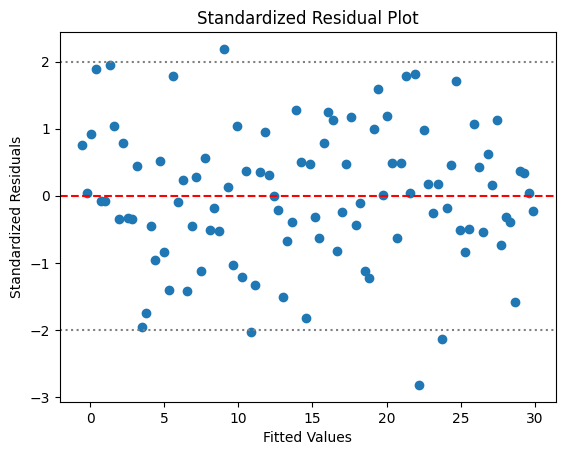

In [4]:
influence = model.get_influence()
standardized_residuals = influence.resid_studentized_internal

plt.scatter(fitted, standardized_residuals)
plt.axhline(0, color="red", linestyle="--")
plt.axhline(2, color="gray", linestyle=":")
plt.axhline(-2, color="gray", linestyle=":")

plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residual Plot")
plt.show()


### PART 5 — Residual Distribution (Histogram)

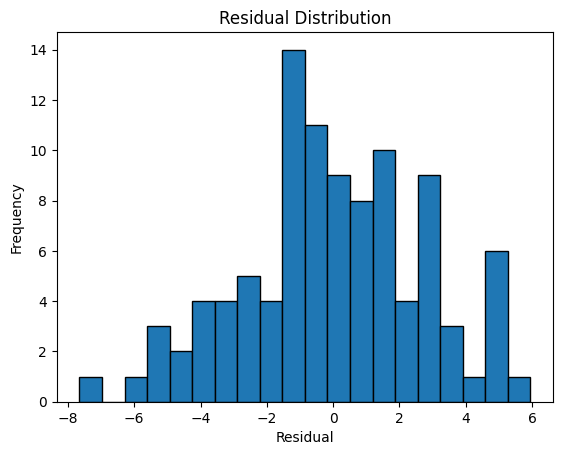

In [5]:
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


### PART 6 — Residual KDE Plot

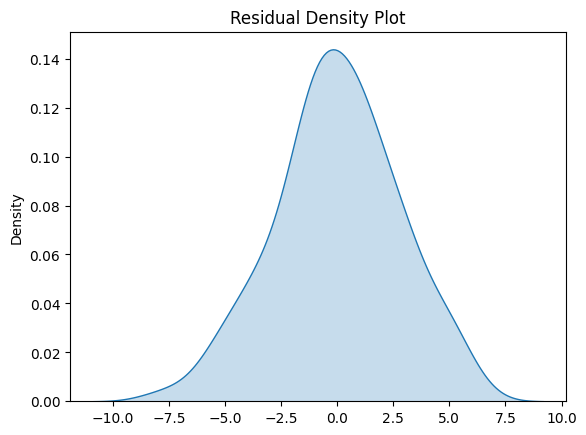

In [7]:
sns.kdeplot(residuals, fill=True)
plt.title("Residual Density Plot")
plt.show()


### PART 7 — Q–Q Plot (Normality Check)

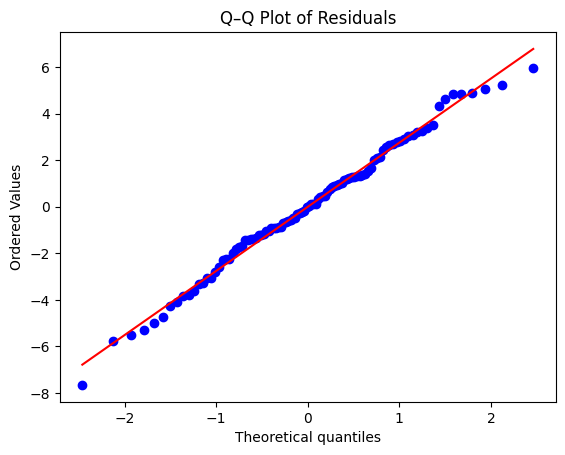

In [8]:
import scipy.stats as stats

stats.probplot(residuals, plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()


### PART 8 — Scale–Location Plot (Homoscedasticity)

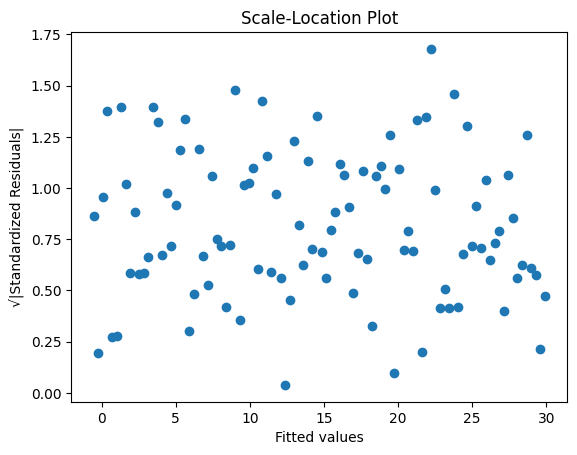

In [9]:
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))

plt.scatter(fitted, sqrt_abs_resid)
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized Residuals|")
plt.title("Scale-Location Plot")
plt.show()


### PART 9 — Leverage vs Residuals (Cook’s Distance)

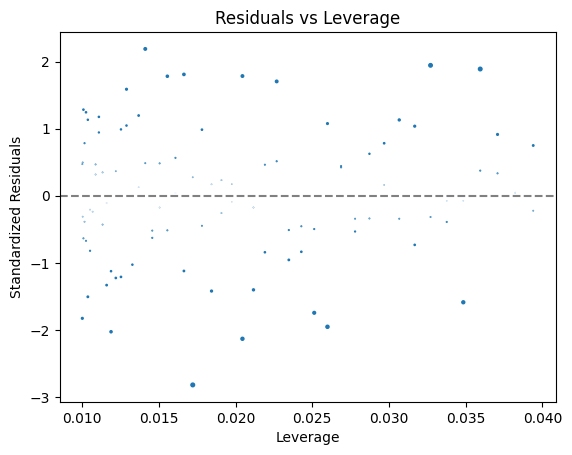

In [10]:
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

plt.scatter(leverage, standardized_residuals, s=100 * cooks)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Residuals vs Leverage")
plt.show()


### PART 10 — Full Regression Diagnostic Panel (4-in-1)

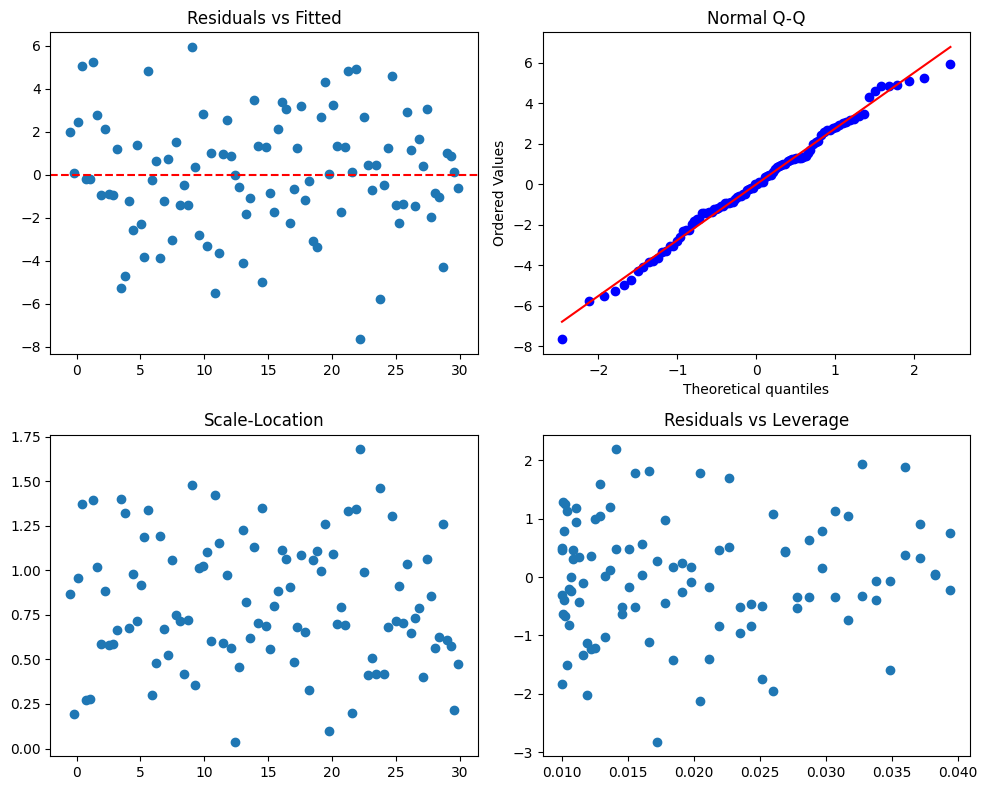

In [11]:
fig = plt.figure(figsize=(10, 8))

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(221)
ax1.scatter(fitted, residuals)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title("Residuals vs Fitted")

# 2. Q-Q Plot
ax2 = fig.add_subplot(222)
stats.probplot(residuals, plot=ax2)
ax2.set_title("Normal Q-Q")

# 3. Scale-Location
ax3 = fig.add_subplot(223)
ax3.scatter(fitted, np.sqrt(np.abs(standardized_residuals)))
ax3.set_title("Scale-Location")

# 4. Residuals vs Leverage
ax4 = fig.add_subplot(224)
ax4.scatter(leverage, standardized_residuals)
ax4.set_title("Residuals vs Leverage")

plt.tight_layout()
plt.show()


### PART 11 — Residual Plot for Polynomial Regression

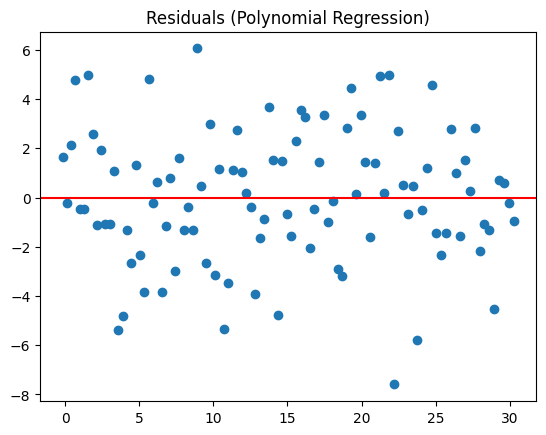

In [12]:
df["X2"] = df["X"] ** 2
X_poly = sm.add_constant(df[["X", "X2"]])
model_poly = sm.OLS(df["Y"], X_poly).fit()

res_poly = model_poly.resid
fitted_poly = model_poly.fittedvalues

plt.scatter(fitted_poly, res_poly)
plt.axhline(0, color="red")
plt.title("Residuals (Polynomial Regression)")
plt.show()


### PART 12 — Residuals for Multiple Regression


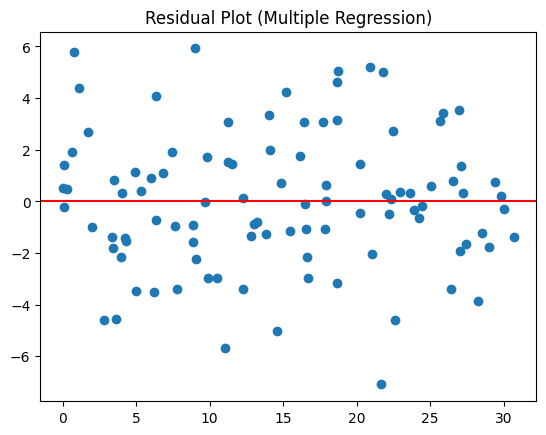

In [13]:
df["X2"] = np.random.normal(0, 1, len(df))
df["X3"] = np.random.normal(2, 1, len(df))

X_multi = sm.add_constant(df[["X", "X2", "X3"]])
model_multi = sm.OLS(df["Y"], X_multi).fit()

resid_multi = model_multi.resid
fitted_multi = model_multi.fittedvalues

plt.scatter(fitted_multi, resid_multi)
plt.axhline(0, color="red")
plt.title("Residual Plot (Multiple Regression)")
plt.show()


### PART 13 — Reusable Residual Diagnostic Function

In [14]:
def residual_diagnostics(X, y):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    fitted = model.fittedvalues
    residuals = model.resid
    influence = model.get_influence()
    std_resid = influence.resid_studentized_internal
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].scatter(fitted, residuals)
    axes[0, 0].axhline(0, color='red')
    axes[0, 0].set_title("Residuals vs Fitted")

    stats.probplot(residuals, plot=axes[0, 1])
    axes[0, 1].set_title("Q-Q Plot")

    axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)))
    axes[1, 0].set_title("Scale-Location")

    axes[1, 1].scatter(influence.hat_matrix_diag, std_resid)
    axes[1, 1].set_title("Residuals vs Leverage")

    plt.tight_layout()
    plt.show()
